# Coreset Benchmarking — Version Finale

This notebook benchmarks five coreset selection strategies on CIFAR-10 using Resnet50 embeddings.

**Methods evaluated:**
- Random
- KMeans
- KCenter (Greedy)
- HDBSCAN + KMeans (Medoids)

**Quality metrics:** Coverage@1 and Density@5

## 1. Imports

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow import keras
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
import hdbscan
import numpy as np
import random
import warnings
warnings.filterwarnings("ignore")

## 2. Configuration

In [4]:
SEED         = 42
CORESET_SIZE = 20   # percentage of each class to keep in the coreset

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 3. Data Loading

In [5]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize to [0, 1]
X_train, X_test = X_train / 255.0, X_test / 255.0

# Split test set into test / validation
X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.2, random_state=SEED
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"Val   : {X_val.shape}")

class_names = ['plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

Train : (50000, 32, 32, 3)
Test  : (8000, 32, 32, 3)
Val   : (2000, 32, 32, 3)


## 4. Feature Extractor — Resnet50 (upscaled to 224×224)

> **Note:** Using native 32×32 inputs yields degraded embeddings. Images are upscaled to 224×224 before passing through Resnet50.

In [6]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input

class ResizeLayer(keras.layers.Layer):
    def __init__(self, target_size=(224, 224), **kwargs):
        super().__init__(**kwargs)
        self.target_size = target_size

    def call(self, x):
        return tf.image.resize(x, self.target_size)

    def get_config(self):
        return {**super().get_config(), 'target_size': self.target_size}


class PreprocessResNet(keras.layers.Layer):
    def call(self, x):
        return resnet_preprocess_input(x * 255.0)


class L2Normalize(keras.layers.Layer):
    def call(self, x):
        return tf.math.l2_normalize(x, axis=1)


def build_resnet50_extractor():
    bb = ResNet50(
        include_top=False,
        weights='imagenet',
        pooling='avg',
        input_shape=(224, 224, 3)
    )
    bb.trainable = False

    inp = keras.Input(shape=(32, 32, 3))
    x   = ResizeLayer(target_size=(224, 224))(inp)
    x   = PreprocessResNet()(x)
    x   = bb(x, training=False)
    out = L2Normalize()(x)
    return Model(inp, out, name='resnet50_extractor')


resnet50_extractor = build_resnet50_extractor()
resnet50_extractor.summary()

I0000 00:00:1779840126.143807  304157 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4149 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "resnet50_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resize_layer (ResizeLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_res_net              │ (None, 224, 224, 3)    │             0 │
│ (PreprocessResNet)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize (L2Normalize)      │ (None, 2048)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [7]:
def extract_embeddings(images, model, batch_size=64):
    embeddings = []
    for i in range(0, len(images), batch_size):
        embs = model.predict(images[i:i + batch_size], verbose=0)
        embeddings.append(embs)
    return np.vstack(embeddings) if embeddings else np.empty((0, 2048))  # 2048 pour ResNet50

## 5. Per-Class Embedding Extraction

In [9]:
y_train_flat = y_train.flatten()
features_embs = {}

for cls_idx, cls_name in enumerate(class_names):
    idx  = np.where(y_train_flat == cls_idx)[0]
    imgs = X_train[idx]
    print(f"Extracting embeddings: {cls_name} ({len(imgs)} images)...")
    embs = extract_embeddings(imgs, resnet50_extractor)
    features_embs[cls_name] = {
        'embeddings': embs,
        'original_indices': idx
    }

print("\nEmbedding extraction complete.")

Extracting embeddings: plane (5000 images)...
Extracting embeddings: car (5000 images)...
Extracting embeddings: bird (5000 images)...
Extracting embeddings: cat (5000 images)...
Extracting embeddings: deer (5000 images)...
Extracting embeddings: dog (5000 images)...
Extracting embeddings: frog (5000 images)...
Extracting embeddings: horse (5000 images)...
Extracting embeddings: ship (5000 images)...
Extracting embeddings: truck (5000 images)...

Embedding extraction complete.


## 6. Quality Metrics

### Coverage & Density

- **Coverage@k**: fraction of full-set points whose k-NN ball contains at least one coreset point.
- **Density@k**: average number of coreset points inside each full-set point's k-NN ball, normalized.

In [10]:
def coverage(full_embs, cs_embs, k=1):
    if len(cs_embs) == 0:
        return 0.0
    nn_f  = NearestNeighbors(n_neighbors=k + 1, metric='euclidean', n_jobs=-1).fit(full_embs)
    radii = nn_f.kneighbors(full_embs)[0][:, k]
    nn_c  = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1).fit(cs_embs)
    d_cs  = nn_c.kneighbors(full_embs)[0][:, 0]
    return float((d_cs <= radii).mean())

def density(full_embs, cs_embs, k=5, block_size=2000):
    S = len(cs_embs)
    if S == 0:
        return 0.0

    nn_f  = NearestNeighbors(n_neighbors=k + 1, metric='euclidean', n_jobs=-1).fit(full_embs)
    radii = nn_f.kneighbors(full_embs)[0][:, k]   # shape (|T|,)

    nn_c  = NearestNeighbors(metric='euclidean', n_jobs=-1).fit(cs_embs)
    count = 0
    for start in range(0, len(full_embs), block_size):
        block       = full_embs[start:start + block_size]
        block_radii = radii[start:start + block_size]
        results = nn_c.radius_neighbors(
            block, radius=float(block_radii.max()), return_distance=True
        )
        for i, dists in enumerate(results[0]):
            count += int((dists <= block_radii[i]).sum())

    return float(count / (k * S))


def get_coreset_target_size(features_dict, cls, percentage=CORESET_SIZE):
    """Return the number of samples to select for a given class."""
    return int(len(features_dict[cls]['embeddings']) * percentage / 100)

## 7. Coreset Selection Methods

### Method 1 — Random

In [11]:
def select_random(n_total, k, seed=SEED):
    """Select k indices uniformly at random without replacement."""
    return np.random.default_rng(seed).choice(n_total, size=k, replace=False)


coresets_random = {}
for cls in class_names:
    embs = features_embs[cls]['embeddings']
    orig = features_embs[cls]['original_indices']
    k    = get_coreset_target_size(features_embs, cls)
    rel  = select_random(len(embs), k)
    coresets_random[cls] = {
        'global_coreset_indices': orig[rel],
        'embeddings': embs[rel]
    }
    print(f"  {cls}: {k} images selected (Random)")

  plane: 1000 images selected (Random)
  car: 1000 images selected (Random)
  bird: 1000 images selected (Random)
  cat: 1000 images selected (Random)
  deer: 1000 images selected (Random)
  dog: 1000 images selected (Random)
  frog: 1000 images selected (Random)
  horse: 1000 images selected (Random)
  ship: 1000 images selected (Random)
  truck: 1000 images selected (Random)


### Method 2 — KMeans

In [12]:
def select_kmeans(embeddings, k, seed=SEED):
    """
    Select k representative samples via MiniBatchKMeans.
    One medoid (closest point to centroid) is picked per cluster.
    Shortfalls are filled with points closest to the global centroid.
    """
    k        = min(k, len(embeddings))
    km       = MiniBatchKMeans(
        n_clusters=k, random_state=seed, n_init=3, max_iter=100, batch_size=1024
    )
    labels   = km.fit_predict(embeddings)
    selected = []
    for c in range(k):
        idx_c = np.where(labels == c)[0]
        if len(idx_c) == 0:
            continue
        dists = np.sum((embeddings[idx_c] - km.cluster_centers_[c])**2, axis=1)
        selected.append(int(idx_c[np.argmin(dists)]))
    if len(selected) < k:
        pool = [i for i in range(len(embeddings)) if i not in set(selected)]
        gc_  = embeddings[selected].mean(axis=0)
        d    = np.sum((embeddings[pool] - gc_)**2, axis=1)
        selected += [pool[i] for i in np.argsort(d)[:k - len(selected)]]
    return selected


coresets_kmeans = {}
for cls in class_names:
    embs = features_embs[cls]['embeddings']
    orig = features_embs[cls]['original_indices']
    k    = get_coreset_target_size(features_embs, cls)
    rel  = select_kmeans(embs, k)
    coresets_kmeans[cls] = {
        'global_coreset_indices': orig[rel],
        'embeddings': embs[rel]
    }
    print(f"  {cls}: {len(rel)} images selected (KMeans)")

  plane: 1000 images selected (KMeans)
  car: 1000 images selected (KMeans)
  bird: 1000 images selected (KMeans)
  cat: 1000 images selected (KMeans)
  deer: 1000 images selected (KMeans)
  dog: 1000 images selected (KMeans)
  frog: 1000 images selected (KMeans)
  horse: 1000 images selected (KMeans)
  ship: 1000 images selected (KMeans)
  truck: 1000 images selected (KMeans)


### Method 3 — KCenter (Greedy)

In [13]:
def select_kcenter(embeddings, k, seed=SEED):
    """
    Greedy k-center algorithm (farthest-point sampling).
    Iteratively selects the point farthest from the current coreset.
    """
    N         = len(embeddings)
    k         = min(k, N)
    selected  = [random.Random(seed).randint(0, N - 1)]
    min_dists = np.full(N, np.inf)
    for _ in range(k - 1):
        d         = np.sum((embeddings - embeddings[selected[-1]])**2, axis=1)
        min_dists = np.minimum(min_dists, d)
        nxt       = int(np.argmax(min_dists))
        selected.append(nxt)
        min_dists[nxt] = 0
    return selected


coresets_kcenter = {}
for cls in class_names:
    embs = features_embs[cls]['embeddings']
    orig = features_embs[cls]['original_indices']
    k    = get_coreset_target_size(features_embs, cls)
    rel  = select_kcenter(embs, k)
    coresets_kcenter[cls] = {
        'global_coreset_indices': orig[rel],
        'embeddings': embs[rel]
    }
    print(f"  {cls}: {len(rel)} images selected (KCenter)")

  plane: 1000 images selected (KCenter)
  car: 1000 images selected (KCenter)
  bird: 1000 images selected (KCenter)
  cat: 1000 images selected (KCenter)
  deer: 1000 images selected (KCenter)
  dog: 1000 images selected (KCenter)
  frog: 1000 images selected (KCenter)
  horse: 1000 images selected (KCenter)
  ship: 1000 images selected (KCenter)
  truck: 1000 images selected (KCenter)


In [14]:
def hdbscan_budgets(labels, k, unique_clusters):
    """Compute per-cluster sampling budgets proportional to cluster size."""
    cluster_sizes   = {c: int(np.sum(labels == c)) for c in unique_clusters}
    total_clustered = sum(cluster_sizes.values())
    budgets         = {
        c: max(1, round(k * cluster_sizes[c] / total_clustered))
        for c in unique_clusters
    }
    # Fix rounding drift
    diff            = k - sum(budgets.values())
    sorted_clusters = sorted(unique_clusters, key=lambda c: cluster_sizes[c], reverse=True)
    n               = len(sorted_clusters)
    for i in range(abs(diff)):
        budgets[sorted_clusters[i % n]] += 1 if diff > 0 else -1
    return budgets

### Method 4  — HDBSCAN + KMeans (Medoids)

In [15]:
def select_hdbscan_kmeans(embeddings, k, seed=SEED, noise_budget=0.05):
    """
    HDBSCAN clustering followed by KMeans-medoid selection within each cluster.
    A small fraction of the budget (noise_budget) is allocated to noise points.
    Returns: (selected_indices, n_clusters, n_noise)
    """
    N         = len(embeddings)
    k         = min(k, N)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3, core_dist_n_jobs=-1)
    labels    = clusterer.fit_predict(embeddings)
    unique_clusters = [c for c in np.unique(labels) if c != -1]
    n_clusters      = len(unique_clusters)
    n_noise         = int(np.sum(labels == -1))
    rng             = np.random.default_rng(seed)
    selected        = []
    k_noise    = max(1, round(k * noise_budget)) if n_noise > 0 else 0
    k_clusters = k - k_noise
    budgets    = hdbscan_budgets(labels, k_clusters, unique_clusters)
    for c in unique_clusters:
        idx_c        = np.where(labels == c)[0]
        n_pick       = min(budgets[c], len(idx_c))
        cluster_embs = embeddings[idx_c]
        if n_pick == 1:
            # Single medoid: closest point to the cluster centroid
            center = cluster_embs.mean(axis=0)
            dists  = np.sum((cluster_embs - center)**2, axis=1)
            picked = idx_c[[np.argmin(dists)]]
        else:
            # Sub-cluster with KMeans, then pick medoid from each sub-cluster
            km        = MiniBatchKMeans(n_clusters=n_pick, random_state=seed, n_init=3, max_iter=100)
            km_labels = km.fit_predict(cluster_embs)
            picked_relative = []
            for sub_c in range(n_pick):
                sub_idx = np.where(km_labels == sub_c)[0]
                if len(sub_idx) == 0:
                    continue
                dists = np.sum(
                    (cluster_embs[sub_idx] - km.cluster_centers_[sub_c])**2, axis=1
                )
                picked_relative.append(int(sub_idx[np.argmin(dists)]))
            picked = idx_c[picked_relative]
        selected.extend(picked.tolist())
    # Allocate noise budget
    if k_noise > 0 and n_noise > 0:
        noise_idx = np.where(labels == -1)[0]
        selected.extend(
            rng.choice(noise_idx, size=min(k_noise, len(noise_idx)), replace=False).tolist()
        )
    return selected[:k], n_clusters, n_noise


coresets_hdbscan_kmeans = {}
for cls in class_names:
    embs = features_embs[cls]['embeddings']
    orig = features_embs[cls]['original_indices']
    k    = get_coreset_target_size(features_embs, cls)
    rel, n_clusters, n_noise = select_hdbscan_kmeans(embs, k)
    coresets_hdbscan_kmeans[cls] = {
        'global_coreset_indices': orig[rel],
        'embeddings': embs[rel]
    }
    print(f"  {cls}: {len(rel)} images selected (HDBSCAN+KMeans) | clusters={n_clusters} | noise={n_noise}")

  plane: 983 images selected (HDBSCAN+KMeans) | clusters=2 | noise=736
  car: 964 images selected (HDBSCAN+KMeans) | clusters=2 | noise=308
  bird: 982 images selected (HDBSCAN+KMeans) | clusters=4 | noise=2217
  cat: 980 images selected (HDBSCAN+KMeans) | clusters=2 | noise=1750
  deer: 990 images selected (HDBSCAN+KMeans) | clusters=3 | noise=1628
  dog: 960 images selected (HDBSCAN+KMeans) | clusters=6 | noise=2833
  frog: 944 images selected (HDBSCAN+KMeans) | clusters=4 | noise=3012
  horse: 965 images selected (HDBSCAN+KMeans) | clusters=8 | noise=2285
  ship: 965 images selected (HDBSCAN+KMeans) | clusters=3 | noise=832
  truck: 973 images selected (HDBSCAN+KMeans) | clusters=2 | noise=97


## 5. Global Evaluation

Coverage@1 and Density@5 are computed on the concatenated embeddings of all 10 classes.

In [16]:
all_full_embeddings = np.vstack([
    features_embs[cls]['embeddings'] for cls in class_names
])

print(f"Full embedding matrix shape: {all_full_embeddings.shape}")

results = []

print(f"\n{'Method':<25} {'Coverage@1':>12} {'Density@5':>12}")
print("─" * 52)

for name, coreset in [
    ('Random',              coresets_random),
    ('KMeans',              coresets_kmeans),
    ('KCenter',             coresets_kcenter),
    ('HDBSCAN+KMeans',      coresets_hdbscan_kmeans),
]:
    embs = np.vstack([coreset[cls]['embeddings'] for cls in class_names])
    cov  = coverage(all_full_embeddings, embs, k=1)
    den  = density(all_full_embeddings, embs, k=5)
    results.append({'Method': name, 'Coverage@1': cov, 'Density@5': den})
    print(f"{name:<25} {cov:.4f}        {den:.4f}")

Full embedding matrix shape: (50000, 2048)

Method                      Coverage@1    Density@5
────────────────────────────────────────────────────
Random                    0.3594        1.1949
KMeans                    0.4177        1.4797
KCenter                   0.2456        0.4762
HDBSCAN+KMeans            0.4218        1.6395


## 6. Results Summary

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame(results)

def highlight_max(col):
    return ['background-color: lightgreen' if v == col.max() else '' for v in col]

display(df.style.apply(highlight_max, subset=['Coverage@1', 'Density@5']))

,Method,Coverage@1,Density@5
0,Random,0.359360,1.194860
1,KMeans,0.417740,1.479720
2,KCenter,0.245600,0.476160
3,HDBSCAN+KMeans,0.421840,1.639501


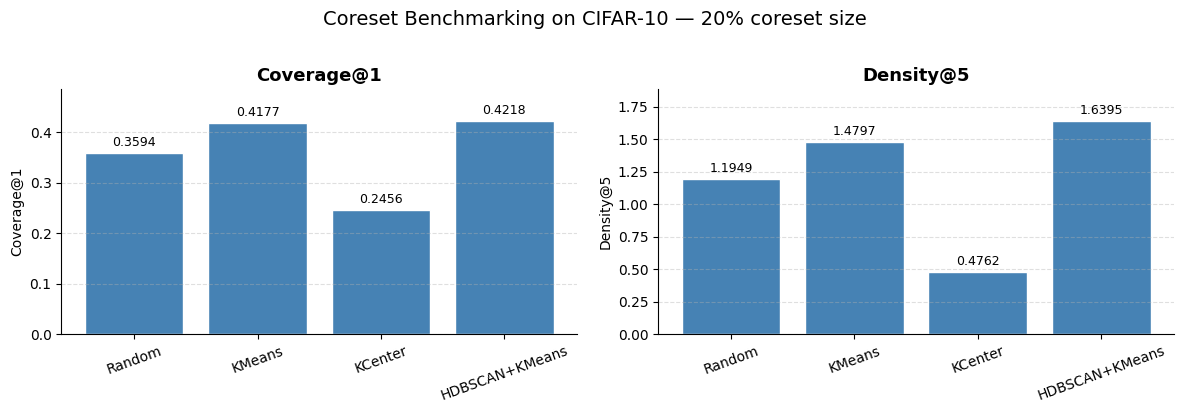

Plot saved to output/coreset_benchmark_results_cifar10.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ['Coverage@1', 'Density@5']):
    bars = ax.bar(df['Method'], df[metric], color='steelblue', edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, df[metric].max() * 1.15)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    f'Coreset Benchmarking on CIFAR-10 — {CORESET_SIZE}% coreset size',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig('results_coreset_selection/coreset_benchmark_results_cifar10.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to results_coreset_selection/coreset_benchmark_results_cifar10.png")